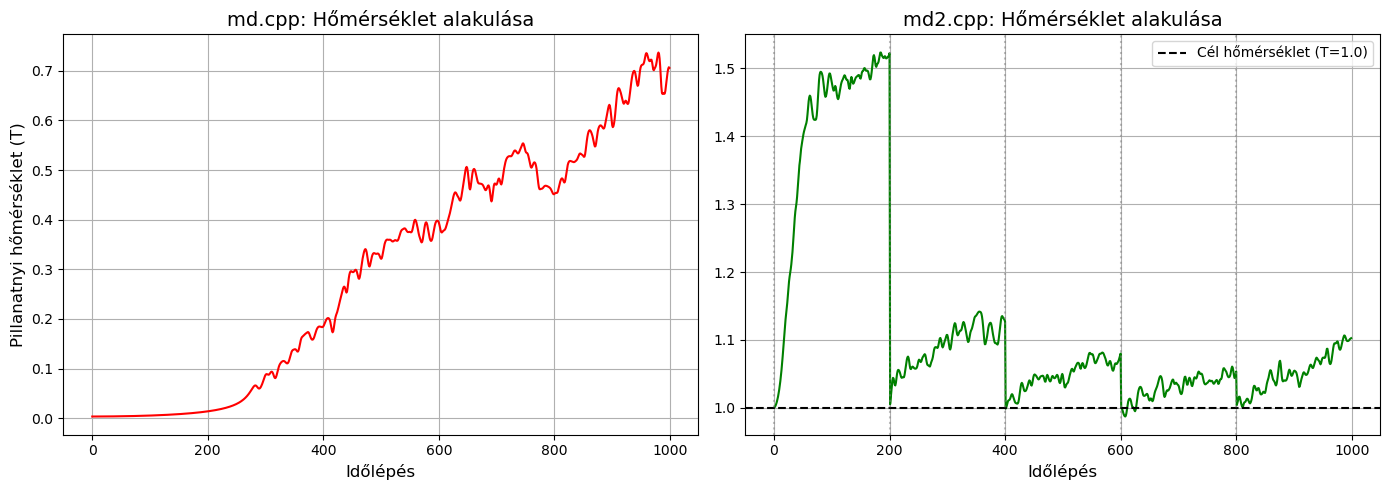

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    T1 = np.loadtxt("datas/T.data")
    T2 = np.loadtxt("datas/T2.data")
except OSError:
    print("Hiba: Nincs meg a datas/T.data vagy a datas/T2.data!")
    exit()

steps = np.arange(len(T1))

fig, axs = plt.subplots(1, 2, figsize = (14, 5))

axs[0].plot(steps, T1, color = "red", linewidth = 1.5)
axs[0].set_title("md.cpp: Hőmérséklet alakulása", fontsize = 14)
axs[0].set_xlabel("Időlépés", fontsize = 12)
axs[0].set_ylabel("Pillanatnyi hőmérséklet (T)", fontsize = 12)
axs[0].grid(True)

axs[1].plot(steps, T2, color = "green", linewidth = 1.5)
axs[1].axhline(1.0, color = "black", linestyle = "--", label = "Cél hőmérséklet (T=1.0)")
for i in range(0, 1000, 200):
    axs[1].axvline(i, color = "gray", linestyle = ":", alpha = 0.5)

axs[1].set_title("md2.cpp: Hőmérséklet alakulása", fontsize = 14)
axs[1].set_xlabel("Időlépés", fontsize = 12)
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.savefig("md_vs_md2_homerseklet.pdf")
plt.show()

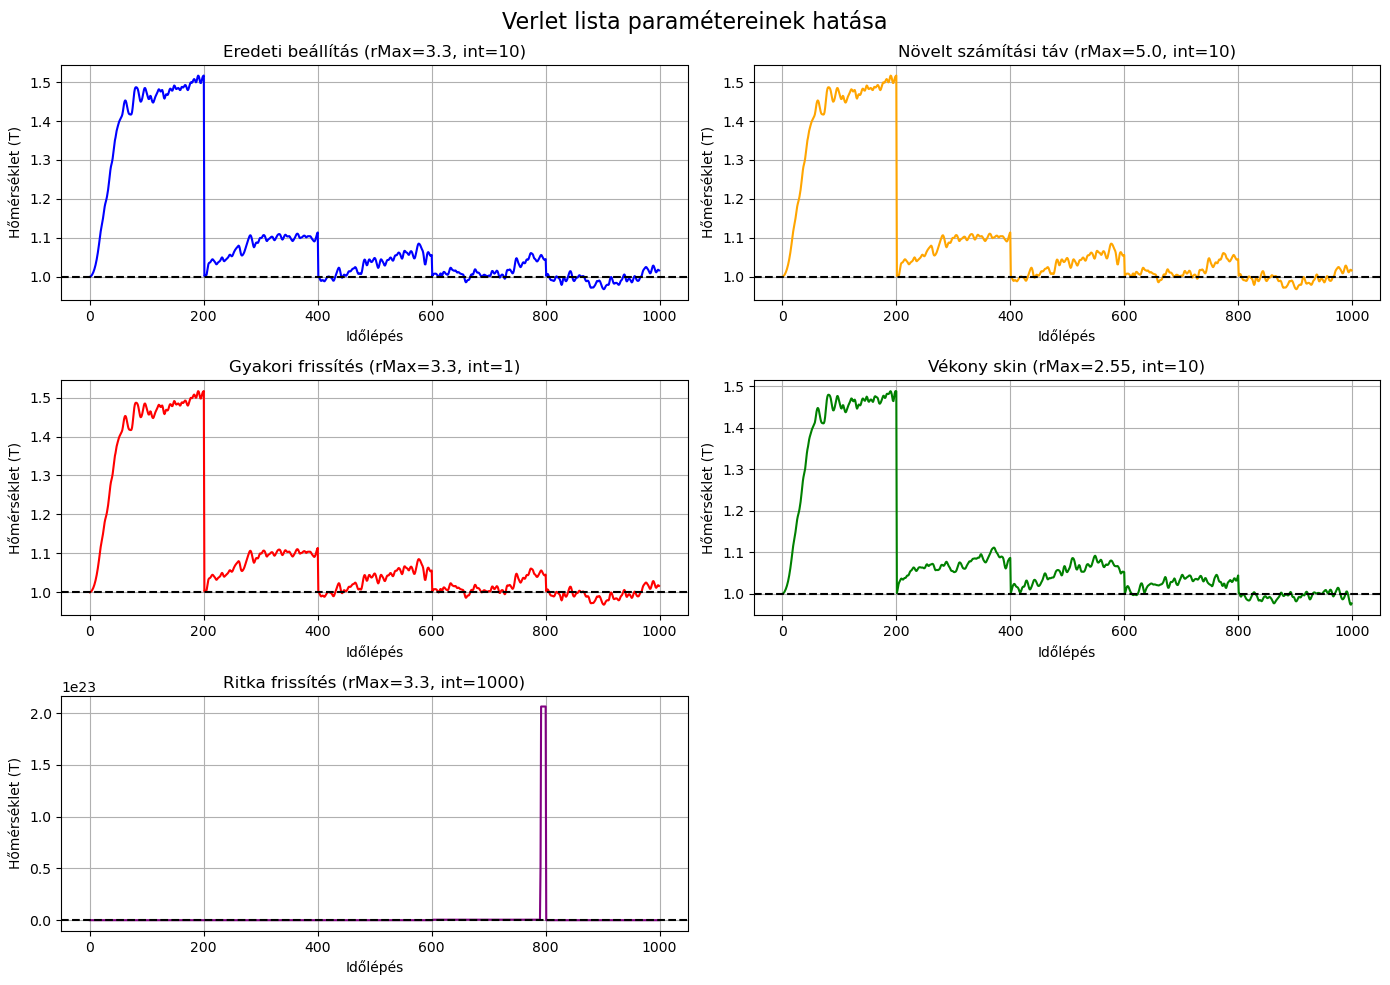

In [2]:
import numpy as np
import matplotlib.pyplot as plt

files = ["datas/T3_1.data", "datas/T3_2.data", "datas/T3_3.data", "datas/T3_4.data", "datas/T3_5.data"]
titles = [
    "Eredeti beállítás (rMax=3.3, int=10)",
    "Növelt számítási táv (rMax=5.0, int=10)",
    "Gyakori frissítés (rMax=3.3, int=1)",
    "Vékony skin (rMax=2.55, int=10)",
    "Ritka frissítés (rMax=3.3, int=1000)"
]
colors = ["blue", "orange", "red", "green", "purple"]

data = []
try:
    for f in files:
        data.append(np.loadtxt(f))
except OSError as e:
    print(f"Hiba: Nem találom az egyik adatfájlt! ({e})")
    exit()

steps = np.arange(len(data[0]))

fig, axs = plt.subplots(3, 2, figsize = (14, 10))
axs = axs.flatten()

for i in range(5):
    axs[i].plot(steps, data[i], color = colors[i])
    axs[i].axhline(1.0, color = "black", linestyle = "--")
    axs[i].set_title(titles[i], fontsize = 12)
    axs[i].set_xlabel("Időlépés")
    axs[i].set_ylabel("Hőmérséklet (T)")
    axs[i].grid(True)

# A 6., felesleges panelt elrejtjük
axs[5].axis("off")

plt.suptitle("Verlet lista paramétereinek hatása", fontsize = 16)
plt.tight_layout()
plt.savefig("md3_verlet_list_teszt.pdf")
plt.show()

md2 idő: 20.2373 s
md3_1: 0.617678 s
md3_2: 0.999307 s
md3_3: 3.74329 s
md3_4: 0.519929 s
md3_5: 0.192487 s

sűrűség: 0.2

<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
C:\Users\krucs\AppData\Local\Temp\ipykernel_4520\3229290975.py:38: SyntaxWarning: invalid escape sequence '\D'
  axs[i].set_ylabel("$\Delta$ Hőmérséklet")


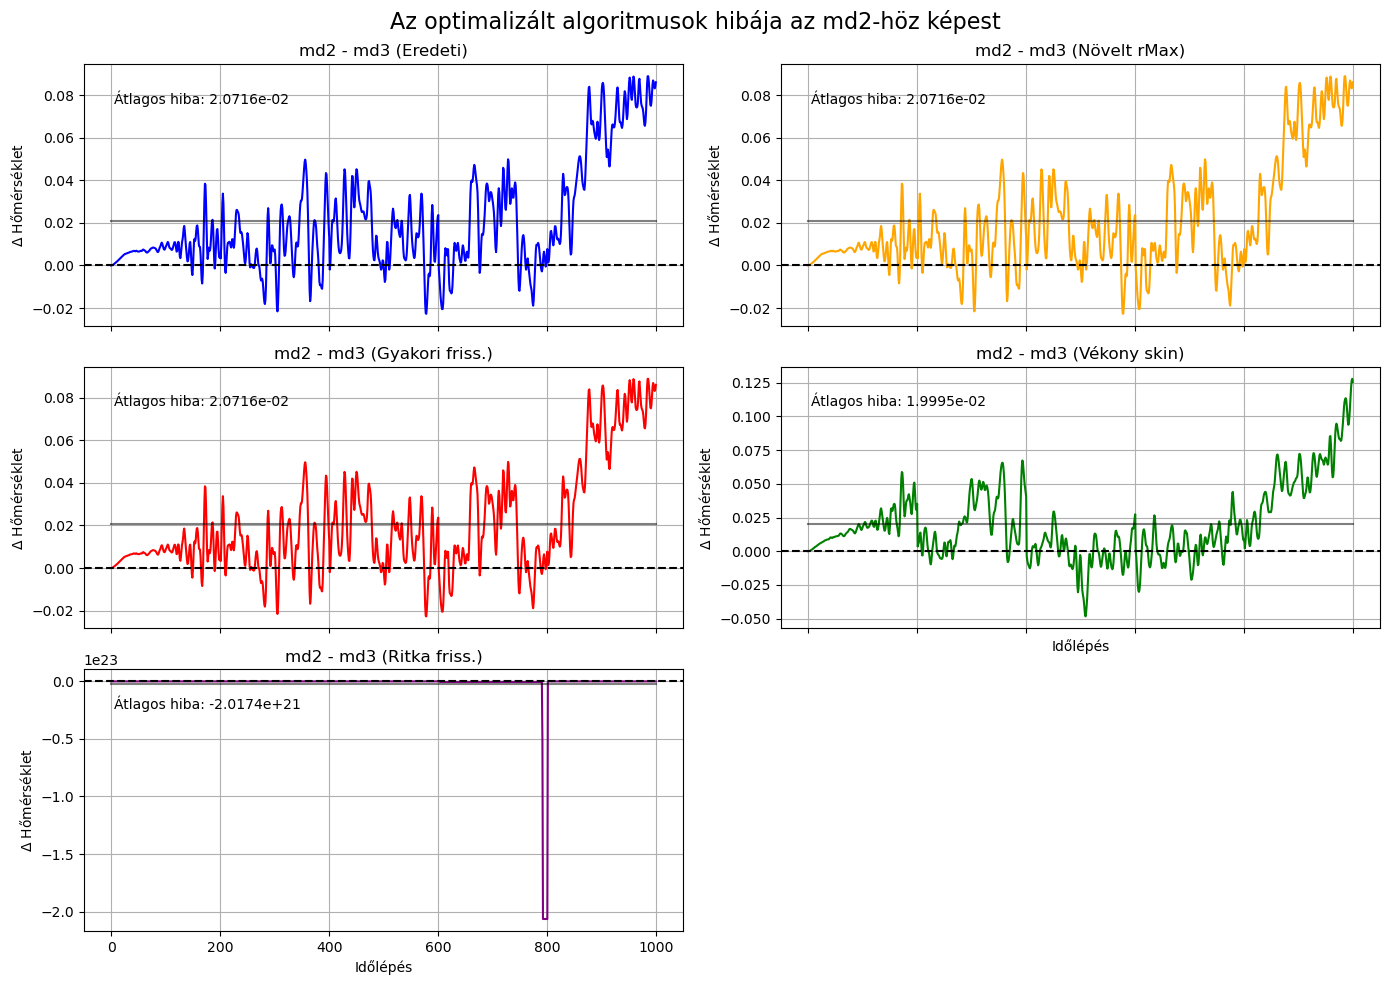

In [2]:
import numpy as np
import matplotlib.pyplot as plt

files_md3 = ["datas/T3_1.data", "datas/T3_2.data", "datas/T3_3.data", "datas/T3_4.data", "datas/T3_5.data"]
titles = [
    "md2 - md3 (Eredeti)",
    "md2 - md3 (Növelt rMax)",
    "md2 - md3 (Gyakori friss.)",
    "md2 - md3 (Vékony skin)",
    "md2 - md3 (Ritka friss.)"
]
colors = ["blue", "orange", "red", "green", "purple"]

try:
    T2 = np.loadtxt("datas/T2.data")
    data_md3 = [np.loadtxt(f) for f in files_md3]
except OSError as e:
    print(f"Hiba fájlbeolvasáskor: {e}")
    exit()

# Biztosítjuk a közös hosszt
lengths = [len(T2)] + [len(d) for d in data_md3]
min_len = min(lengths)

T2 = T2[:min_len]
steps = np.arange(min_len)

fig, axs = plt.subplots(3, 2, figsize = (14, 10), sharex = True)
axs = axs.flatten()

for i in range(5):
    diff = T2 - data_md3[i][:min_len]
    axs[i].plot(steps, diff, color = colors[i])
    axs[i].plot(steps, np.mean(diff)*np.ones_like(steps), color = "black", alpha = 0.5, label = "Átlagos eltérés")
    axs[i].text(0.05, 0.85, f"Átlagos hiba: {np.mean(diff):.4e}", transform = axs[i].transAxes, fontsize = 10)
    axs[i].axhline(0, color = "black", linestyle = "--", linewidth = 1.5)
    axs[i].set_title(titles[i], fontsize = 12)
    axs[i].set_ylabel("$\Delta$ Hőmérséklet")
    axs[i].grid(True)
    if i >= 3:
        axs[i].set_xlabel("Időlépés")

axs[5].axis("off")

plt.suptitle("Az optimalizált algoritmusok hibája az md2-höz képest", fontsize = 16)
plt.tight_layout()
plt.savefig("md3_pontossag_elteres.pdf")
plt.show()

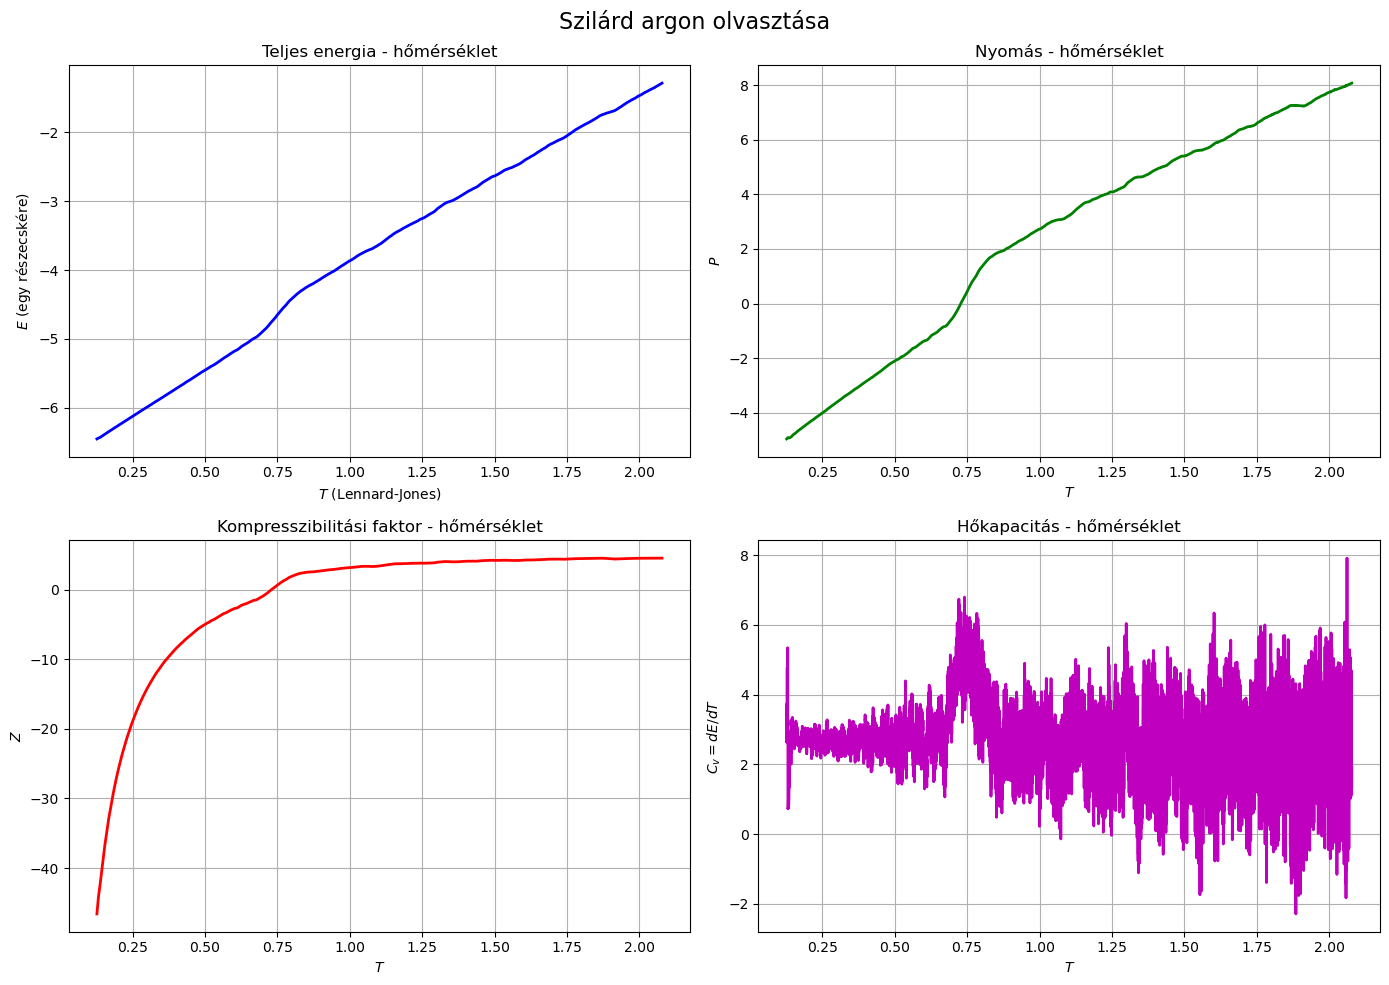

In [3]:
import numpy as np
import matplotlib.pyplot as plt

try:
    data = np.loadtxt("datas/thermo.data", skiprows = 1)
except OSError:
    print("Hiba: Nem található a datas/thermo.data fájl!")
    exit()

T_inst = data[:, 0]
E_tot = data[:, 1]
P = data[:, 2]
Z = data[:, 3]

idx = np.argsort(T_inst)
T_inst = T_inst[idx]
E_tot = E_tot[idx]
P = P[idx]
Z = Z[idx]

window = 500
T_smooth = np.convolve(T_inst, np.ones(window)/window, mode = "valid")
E_smooth = np.convolve(E_tot, np.ones(window)/window, mode = "valid")
P_smooth = np.convolve(P, np.ones(window)/window, mode = "valid")
Z_smooth = np.convolve(Z, np.ones(window)/window, mode = "valid")

Cv = np.gradient(E_smooth, T_smooth)

fig, axs = plt.subplots(2, 2, figsize = (14, 10))

# 1. Energia
axs[0, 0].plot(T_smooth, E_smooth, "b-", linewidth = 2)
axs[0, 0].set_title("Teljes energia - hőmérséklet")
axs[0, 0].set_xlabel("$T$ (Lennard-Jones)")
axs[0, 0].set_ylabel("$E$ (egy részecskére)")
axs[0, 0].grid(True)

# 2. Nyomás
axs[0, 1].plot(T_smooth, P_smooth, "g-", linewidth = 2)
axs[0, 1].set_title("Nyomás - hőmérséklet")
axs[0, 1].set_xlabel("$T$")
axs[0, 1].set_ylabel("$P$")
axs[0, 1].grid(True)

# 3. Kompresszibilitás (Z)
axs[1, 0].plot(T_smooth, Z_smooth, "r-", linewidth = 2)
axs[1, 0].set_title("Kompresszibilitási faktor - hőmérséklet")
axs[1, 0].set_xlabel("$T$")
axs[1, 0].set_ylabel("$Z$")
axs[1, 0].grid(True)

# 4. Hőkapacitás (Cv)
axs[1, 1].plot(T_smooth, Cv, "m-", linewidth = 2)
axs[1, 1].set_title("Hőkapacitás - hőmérséklet")
axs[1, 1].set_xlabel("$T$")
axs[1, 1].set_ylabel("$C_v = dE/dT$")
axs[1, 1].grid(True)

plt.suptitle("Szilárd argon olvasztása", fontsize = 16)
plt.tight_layout()
plt.savefig("fazisatalakulas.pdf")
plt.show()
# 0.85 volt a sűrűség

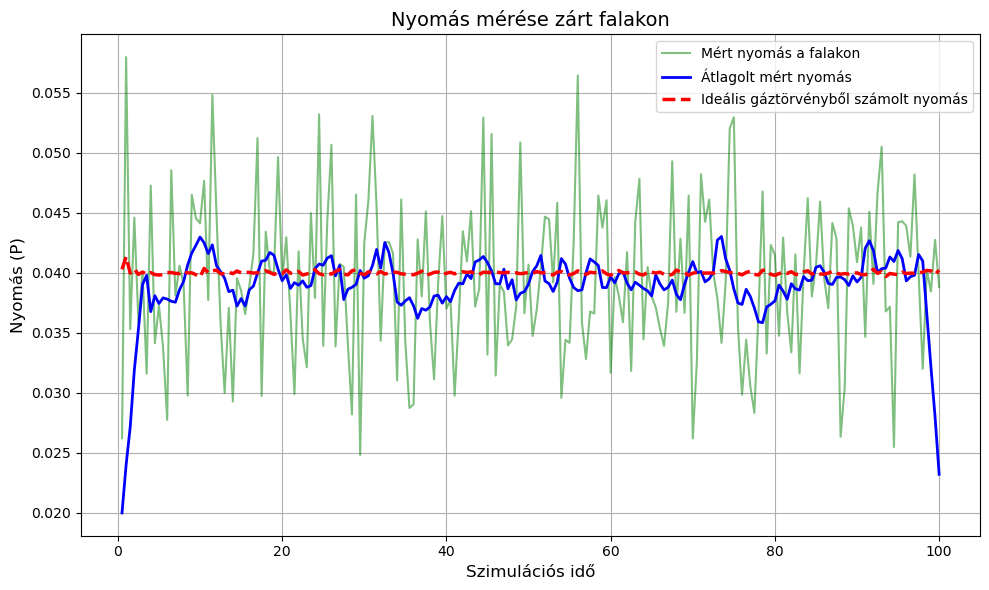

Az átlagos mért nyomás: 0.0395
Az átlagos elméleti nyomás: 0.0400
Az eltérés a kettő között: 1.27%


In [5]:
import numpy as np
import matplotlib.pyplot as plt

try:
    data = np.loadtxt("datas/pressure.data", skiprows=1)
except OSError:
    print("Hiba: Nincs meg a datas/pressure.data!")
    exit()

time = data[:, 0]
P_measured = data[:, 1]
P_ideal = data[:, 2]

window = 10
P_measured_smooth = np.convolve(P_measured, np.ones(window) / window, mode = "same")

plt.figure(figsize = (10, 6))

plt.plot(time, P_measured, color = "green", alpha = 0.5, label = "Mért nyomás a falakon")
plt.plot(time, P_measured_smooth, color = "blue", linewidth = 2, label = "Átlagolt mért nyomás")
plt.plot(time, P_ideal, color = "red", linestyle = "--", linewidth = 2.5, label = "Ideális gáztörvényből számolt nyomás")

plt.title("Nyomás mérése zárt falakon", fontsize = 14)
plt.xlabel("Szimulációs idő", fontsize = 12)
plt.ylabel("Nyomás (P)", fontsize = 12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("idealis_gaz_torveny.pdf")
plt.show()

avg_P_meas = np.mean(P_measured[20:])
avg_P_ideal = np.mean(P_ideal[20:])
hiba_szazalek = abs(avg_P_meas - avg_P_ideal) / avg_P_ideal * 100

print(f"Az átlagos mért nyomás: {avg_P_meas:.4f}")
print(f"Az átlagos elméleti nyomás: {avg_P_ideal:.4f}")
print(f"Az eltérés a kettő között: {hiba_szazalek:.2f}%")
# 0.02 volt a sűrűség